Develop code for a function that achieves the following:
- Input the number of electrodes you are using
- Input electrode correlations between electrode and Cz (reference), e.g., 5 electrodes that are 0.8 correlated, 4 that are 0.2 correlated, etc.
- Code calculates PSD for each electrode and then averages PSDs together to return 1 average PSD for all chosen electrodes
- This would be for 1 ppt

In [1]:
def simulate_average_psd(corr_structure, seed=256, n_seconds=10, s_rate=250):
    # necessary imports defined
    import numpy as np
    from neurodsp.spectral import compute_spectrum_welch
    from simulate_cz_signal import generate_cz_signal
    
    np.random.seed(seed)

    # Generate Cz reference signal
    cz_signal = generate_cz_signal(seed=seed, n_seconds=n_seconds, s_rate=s_rate)

    sigma_source = np.std(cz_signal)

    psds = []
    electrode_count = 0

    # Loop through each correlation level
    for rho, n_elecs in corr_structure.items():

        for _ in range(n_elecs):
            # Calculate required noise SD
            noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
            noise = noise_std * np.random.randn(len(cz_signal))

            # Create correlated signal
            signal = rho * cz_signal + noise

            # Compute PSD
            freqs, powers = compute_spectrum_welch(signal, fs=s_rate)
            psds.append(powers)

            electrode_count += 1

    # Convert to array
    psds = np.array(psds)

    # Average across electrodes
    avg_psd = np.mean(psds, axis=0)

    print(f"Total electrodes simulated: {electrode_count}")

    return freqs, avg_psd

In [2]:
corr_structure = {
    0.8: 5,
    0.2: 4}

freqs, avg_psd = simulate_average_psd(corr_structure)

Total electrodes simulated: 9


In [3]:
from neurodsp.plts import plot_power_spectra
from specparam import SpectralModel
from specparam.plts import plot_spectra

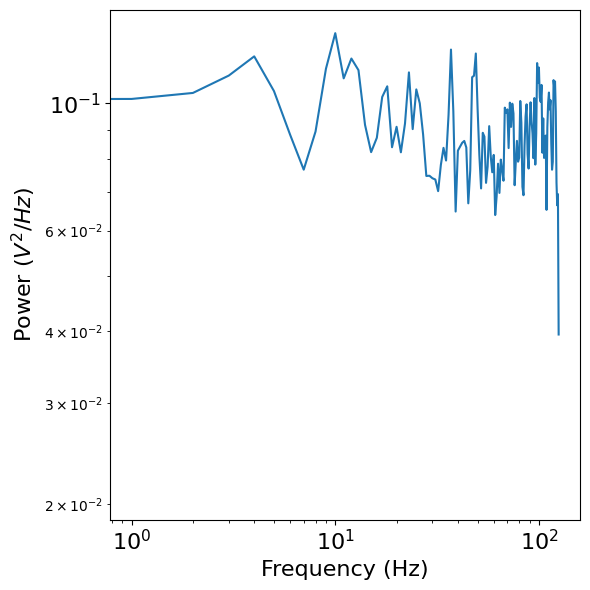

In [4]:
plot_power_spectra(freqs, avg_psd)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



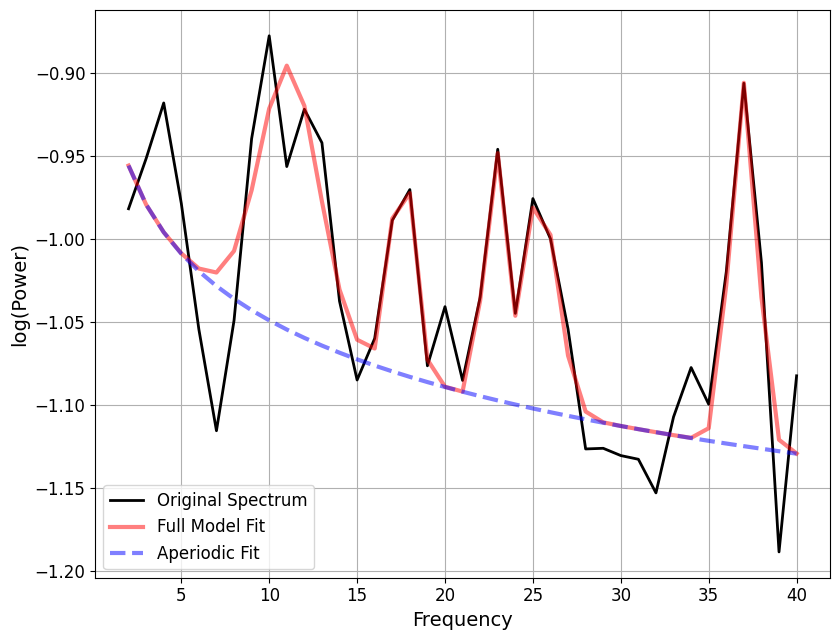

In [5]:
fm = SpectralModel()
freq_range = [2, 40]
    
fm.fit(freqs, avg_psd, freq_range)
fm.plot()

In [6]:
corr_structure = {
    1.0: 1,
    0.8: 8,
    0.6: 16,
    0.4: 16,
    0.2: 20}

freqs, avg_psd = simulate_average_psd(corr_structure)

Total electrodes simulated: 61


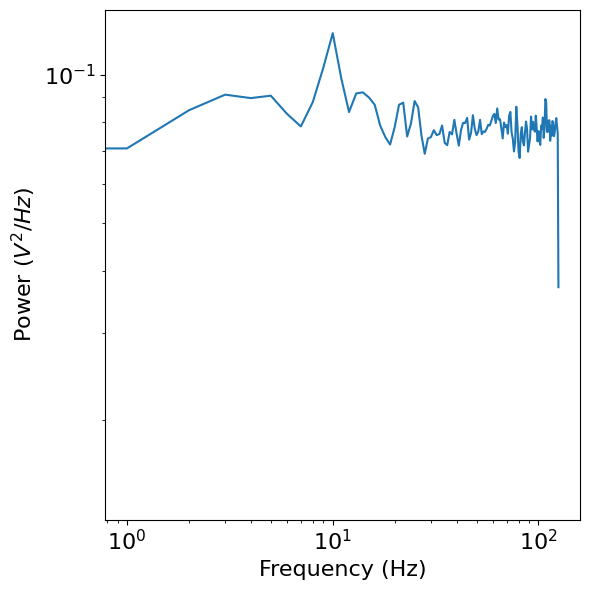

In [7]:
plot_power_spectra(freqs, avg_psd)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



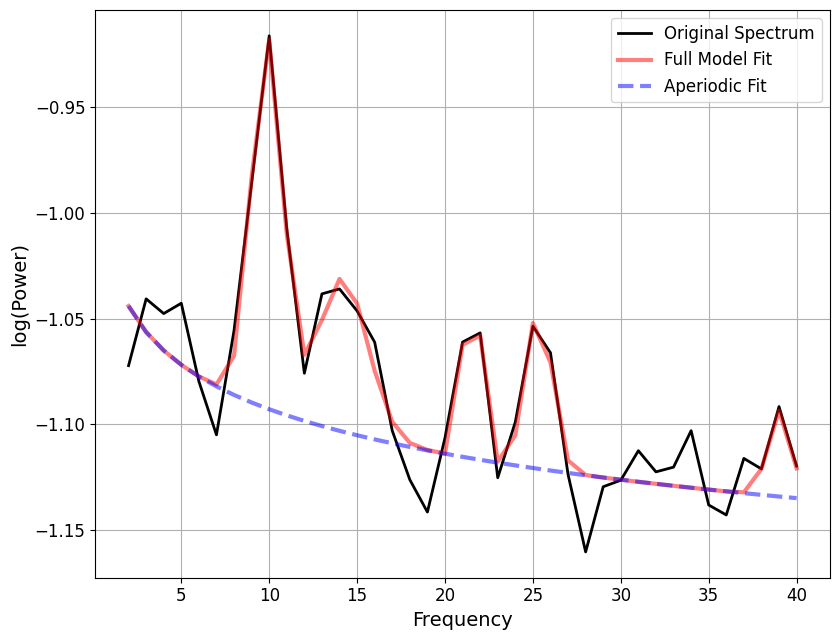

In [8]:
fm = SpectralModel()
freq_range = [2, 40]
    
fm.fit(freqs, avg_psd, freq_range)
fm.plot()